In [ ]:
!wget "https://raw.githubusercontent.com/SJGuy-UMN/CSCI4521/refs/heads/main/clickbait_data.csv"

--2026-02-28 04:11:52--  https://raw.githubusercontent.com/SJGuy-UMN/CSCI4521/refs/heads/main/clickbait_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1835039 (1.8M) [text/plain]
Saving to: ‘clickbait_data.csv.4’

clickbait_data.csv. 100%[===================>]   1.75M  --.-KB/s    in 0.1s    

2026-02-28 04:11:53 (11.9 MB/s) - ‘clickbait_data.csv.4’ saved [1835039/1835039]



Q1. Vectorization & Data Prep

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df = pd.read_csv("clickbait_data.csv")
df = df.dropna(subset=["headline", "clickbait"]).reset_index(drop=True)

In [ ]:
#check len
print(len(df))

32000


In [ ]:
#subsample because the dataset is large
RANDOM_STATE = 42
N= 20000
df = df.sample(n=N, random_state=RANDOM_STATE).reset_index(drop=True)
print(len(df))



20000


In [ ]:
#Extract text and labels
text = df["headline"].astype(str)
labels = df["clickbait"].astype(int)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english',lowercase=True, max_features=5000)
X_train = vectorizer.fit_transform(text)

In [ ]:
#Report of Statitics
print("Size of sample:", X_train.shape[0])
print("Features:", X_train.shape[1])

count_clickbait = np.sum(labels==1)
news_count = np.sum(labels ==0)

print("Clickbait count:", count_clickbait)
print("News count:", news_count)

Size of sample: 20000
Features: 5000
Clickbait count: 10035
News count: 9965


Q2 Binary Clustering

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
K2M = KMeans(n_clusters=2, random_state=RANDOM_STATE)
clusters = K2M.fit_predict(X_train)
print(clusters.shape)


(20000,)


In [ ]:
print(np.sum(clusters==0))
print(np.sum(clusters==1))

709
19291


In [ ]:
#actual percentage of clickbait healdines for comparison
total = len(labels)
clickbait_percentage = (np.sum(labels==1)/total) *100
print("Clickbait percentage:",clickbait_percentage)
news_percentage = (np.sum(labels==0)/total) *100
print("News percentage:", news_percentage)


Clickbait percentage: 50.175000000000004
News percentage: 49.825


Q3. Multi Cluster Analysis

In [ ]:
#from class, TF_IDF with stemming
import nltk.stem
english_stemmer = nltk.stem.SnowballStemmer('english')
class StemmedTfidfVectorizer(TfidfVectorizer):
   def build_analyzer(self):
     analyzer = super(StemmedTfidfVectorizer, self).build_analyzer()
     return lambda doc: (english_stemmer.stem(w) for w in analyzer(doc))

vectorizer = StemmedTfidfVectorizer(min_df=1, stop_words='english')
X_train = vectorizer.fit_transform(text)

In [ ]:
from sklearn.cluster import KMeans
#k=6
k6Means= KMeans(n_clusters=6, init= "random", n_init=10, random_state= RANDOM_STATE, verbose=1)
clusters6=k6Means.fit_predict(X_train)
print("cluster label shape:", k6Means.labels_.shape)
print("cluster label shape:", k6Means.cluster_centers_.shape)

Initialization complete
Iteration 0, inertia 39496.49748066908.
Iteration 1, inertia 19841.17446130712.
Iteration 2, inertia 19831.979947087257.
Iteration 3, inertia 19828.02968653454.
Iteration 4, inertia 19827.6432598532.
Iteration 5, inertia 19827.58564879633.
Iteration 6, inertia 19827.553790210597.
Iteration 7, inertia 19827.538707291405.
Converged at iteration 7: strict convergence.
Initialization complete
Iteration 0, inertia 39334.54214489273.
Iteration 1, inertia 19821.190272641426.
Iteration 2, inertia 19811.771697859447.
Iteration 3, inertia 19810.00840836197.
Iteration 4, inertia 19809.964215137014.
Iteration 5, inertia 19809.947233135394.
Iteration 6, inertia 19809.941234098103.
Iteration 7, inertia 19809.937773831123.
Iteration 8, inertia 19809.932944877215.
Converged at iteration 8: strict convergence.
Initialization complete
Iteration 0, inertia 38883.51056749655.
Iteration 1, inertia 19795.716459330662.
Iteration 2, inertia 19781.579841672807.
Iteration 3, inertia 1978

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

tfidf_df= pd.DataFrame(X_train.toarray(), columns=feature_names)

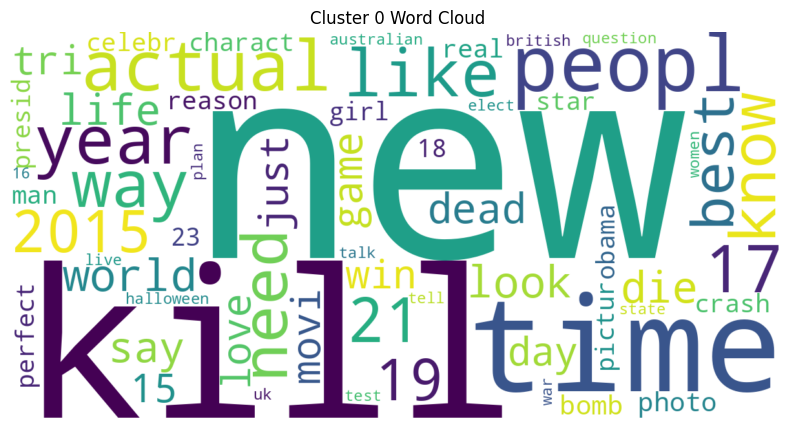

cluster size:  17785


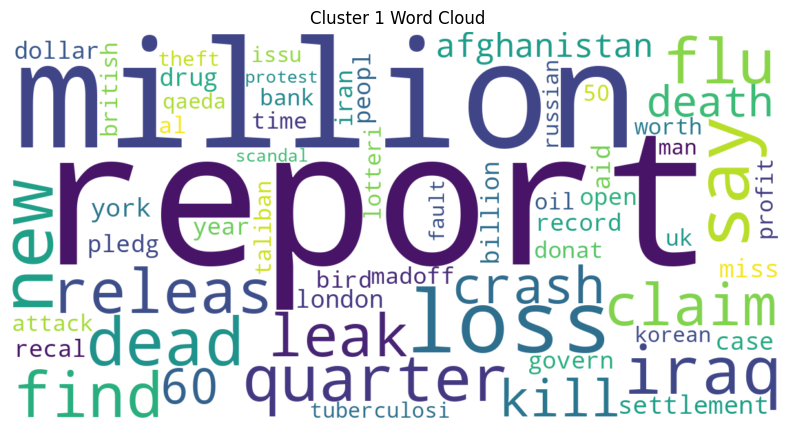

cluster size:  282


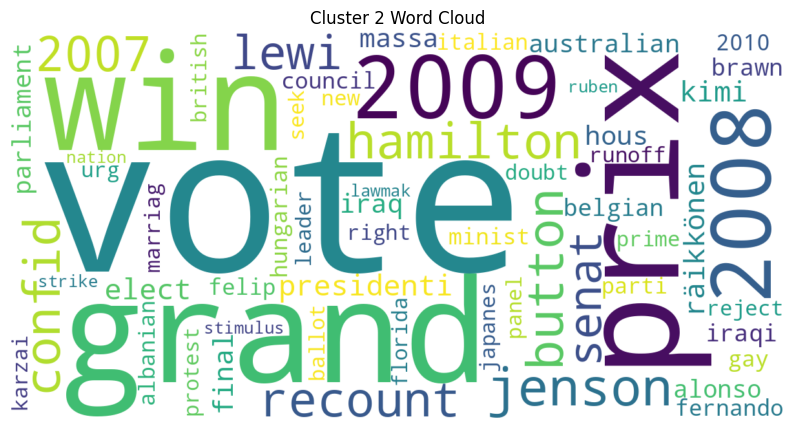

cluster size:  149


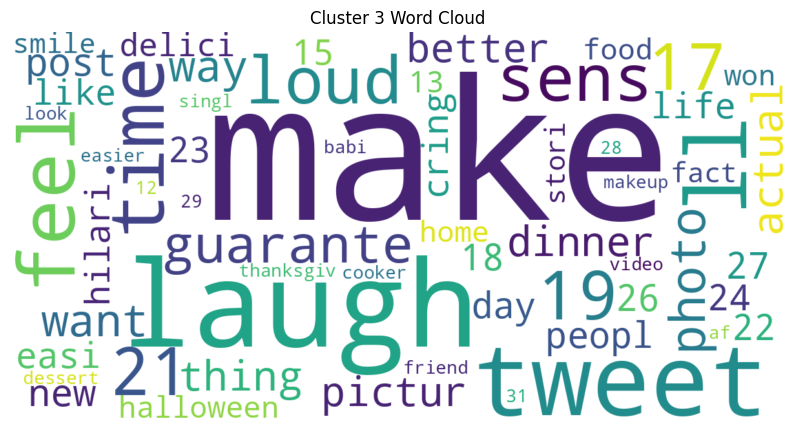

cluster size:  644


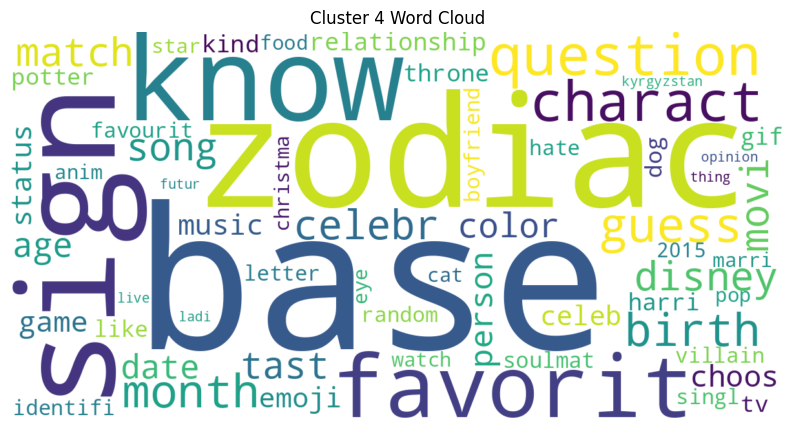

cluster size:  421


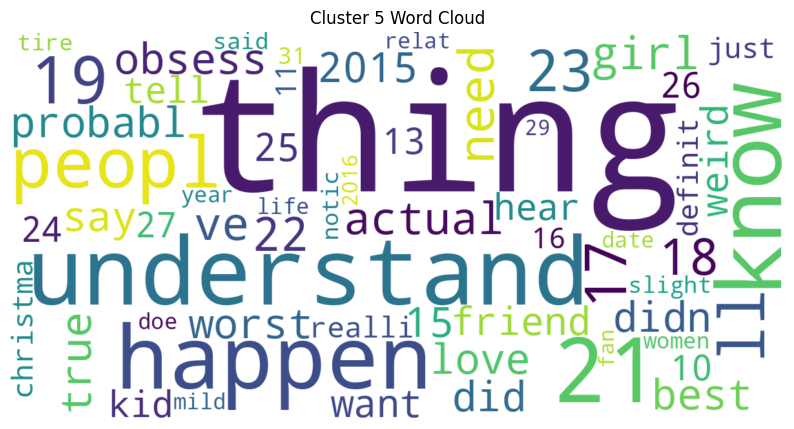

cluster size:  719


In [ ]:
#Word cloud
for cluster_idx in range(6):
  matching_id = (clusters6 == cluster_idx)
  importance = tfidf_df[matching_id].sum(axis=0)
  word_cloud = WordCloud(collocations = False, background_color = 'white', max_words = 60,
                          width = 1200, height = 600).generate_from_frequencies(importance)
  plt.figure(figsize = (10,6))
  plt.imshow(word_cloud,  interpolation='bilinear')
  plt.axis("off")
  plt.title(f"Cluster {cluster_idx} Word Cloud")
  plt.show()
  print("cluster size: ",text[matching_id].size)

In [ ]:
from scipy.spatial.distance import cdist
dist = cdist(X_train.toarray(), k6Means.cluster_centers_, 'cosine')
for cluster_idx in range(6):
  idx= np.where(clusters6 == cluster_idx)[0]
  closest = idx[np.argsort(dist[idx,cluster_idx])[:3]]

  print(f"\nCluster {cluster_idx} - Representative Headlines:")
  for i in closest:
      print(" -", text.iloc[i])



Cluster 0 - Representative Headlines:
 - Here's How People Celebrate The New Year Around The World
 - 21 People Who Really Know What Life Is All About
 - Do You Need A New Best Friend

Cluster 1 - Representative Headlines:
 - The Times Reports Quarterly Loss of $74.5 Million
 - U.S. Open Day 1 Report
 - British Airways Reports $595 Million Annual Loss

Cluster 2 - Representative Headlines:
 - Mugabe: A vote for MDC is a wasted vote
 - Prodi wins vote of confidence
 - German Parliament votes yes on EU constitution; French referendum may vote no

Cluster 3 - Representative Headlines:
 - Can You Make It Through These 29 Tweets Without Laughing Once
 - 19 Tweets About Movies That Will Make You Laugh Every Time
 - 19 Tweets About Celebrities That Will Make You Laugh Every Time

Cluster 4 - Representative Headlines:
 - We Know Your Zodiac Sign Based On Your Favorite Foods
 - We Know Your Favorite TV Show Based On Your Zodiac Sign
 - We Know Your Zodiac Sign Based On Your Favorite Cats

Clus

Q4. Cluster Validation

In [ ]:
#seperate clusters based on majority
cluster_majority = {}
for cluster_id in range(6):
  idx = (clusters6 == cluster_id)
  pct_clickbait =labels[idx].mean()

  if pct_clickbait > 0.5:
    cluster_majority[cluster_id] = "clickbait"
  else:
    cluster_majority[cluster_id] = "news"
  print(f"Cluster {cluster_id}: {cluster_majority[cluster_id]} majority ({pct_clickbait*100:.2f}% clickbait)")

Cluster 0: news majority (46.95% clickbait)
Cluster 1: news majority (7.80% clickbait)
Cluster 2: news majority (2.68% clickbait)
Cluster 3: clickbait majority (84.01% clickbait)
Cluster 4: clickbait majority (95.96% clickbait)
Cluster 5: clickbait majority (99.30% clickbait)


In [ ]:
#find news inside majority clickbait

news_clickbait = []
for i in range(len(text)):
  cluster_id = clusters6[i]
  if cluster_majority[cluster_id] == "clickbait" and labels[i] ==0:
      news_clickbait.append(i)
for i in news_clickbait[:2]:
    print(" -", text.iloc[i])


 - Blagojevich Makes a Day of It on Way Out
 - Yankees Make Last Home Run Count


In [ ]:
#find clickbait in majority news
clickbait_news = []
for i in range(len(text)):
  cluster_id = clusters6[i]
  if cluster_majority[cluster_id] == "news" and labels[i] ==1:
      clickbait_news.append(i)
for i in clickbait_news[:2]:
    print(" -", text.iloc[i])


 - 24 Rules For Women On A First Date With A Man
 - 24 Hauntingly Beautiful Tattoos Featuring No Face From "Spirited Away"


In [ ]:
#Validate new inputs
new_headline =["11 Things You Are Doing Wrong At The Gym", "You Wont Believe What This Guy Did To His Car", "Democrats Accounce Their Plan For The Next Election", "Climate Change Report Updated To Include New Findings From Scientists"]
new_headline_vecs= vectorizer.transform(new_headline)

from scipy.spatial.distance import cdist
dist_new = cdist(new_headline_vecs.toarray(), k6Means.cluster_centers_, 'cosine')
for i, headline in enumerate(new_headline):
  cluster_id = np.argmin(dist_new[i])
  print("\nHeadline:", headline)
  print("Closest cluster:", cluster_id)
  print("Cluster majority:", cluster_majority[cluster_id])
  print("Distances:", np.round(dist_new[i], 3)) # shows distances to all 6 clusters


Headline: 11 Things You Are Doing Wrong At The Gym
Closest cluster: 5
Cluster majority: clickbait
Distances: [0.968 0.996 1.    0.98  0.996 0.715]

Headline: You Wont Believe What This Guy Did To His Car
Closest cluster: 0
Cluster majority: news
Distances: [0.957 0.998 1.    0.987 1.    0.977]

Headline: Democrats Accounce Their Plan For The Next Election
Closest cluster: 0
Cluster majority: news
Distances: [0.931 0.993 0.962 0.996 0.998 0.998]

Headline: Climate Change Report Updated To Include New Findings From Scientists
Closest cluster: 1
Cluster majority: news
Distances: [0.928 0.739 0.989 0.987 0.999 0.991]


Q5: PCA

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

X_train_array = X_train.toarray()
pca = PCA(n_components=3)
pca_result = pca.fit_transform(X_train_array)

pc_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2', 'PC3'])
pc_df['Label'] = labels
pc_df['Headline'] = text.values


In [ ]:
fig = px.scatter_3d(pc_df, x="PC1", y="PC2", z="PC3", color = pc_df["Label"].astype(str),hover_data=["Headline"])
fig.show()

In [ ]:
#find outliers
clickbait_idx = (labels ==1)
news_idx = (labels ==0)

clickbait_centroid = pca_result[clickbait_idx].mean(axis=0)
news_centroid = pca_result[news_idx].mean(axis=0)

clickbait_dist = np.linalg.norm(pca_result[clickbait_idx]- clickbait_centroid, axis=1 )
news_dist = np.linalg.norm(pca_result[news_idx]- news_centroid, axis=1 )

clickbait_outlier_idx = np.where(clickbait_idx)[0][np.argsort(clickbait_dist)[-2:]]
news_outlier_idx = np.where(news_idx)[0][np.argsort(news_dist)[-2:]]

print("Outlier headlines for clickbait:")
for i in clickbait_outlier_idx:
  print(" -", text.iloc[i])
print("\nOutlier headlines for news:")
for i in news_outlier_idx:
  print(" -", text.iloc[i])


Outlier headlines for clickbait:
 - We Know Your Favorite TV Show Based On Your Zodiac Sign
 - We Know Your Zodiac Sign Based On Your Favorite Foods

Outlier headlines for news:
 - Blagojevich Makes a Day of It on Way Out
 - Making Up for Lost Time


In [ ]:
#Variance Analysis
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.00424598 0.00390374 0.00303258]


In [ ]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

svd = TruncatedSVD(n_components=1000, random_state=42)
svd.fit(X_train)

cum_var = np.cumsum(svd.explained_variance_ratio_)

components_50 = np.argmax(cum_var >= 0.50) + 1

print("Components needed for >50% variance:", components_50)


Components needed for >50% variance: 870


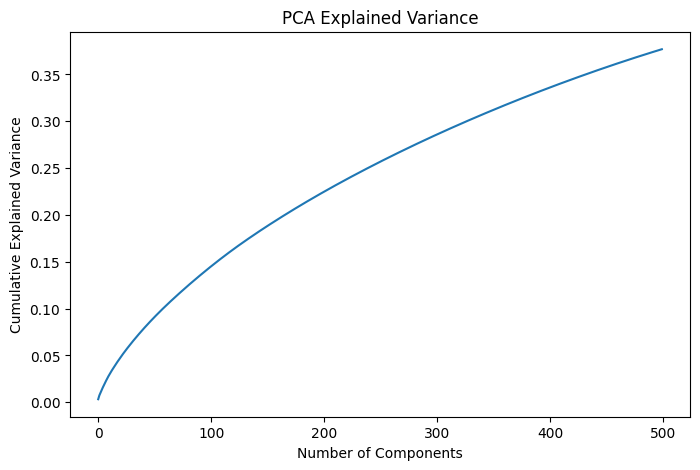

In [ ]:
#visual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(cum_var)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title("PCA Explained Variance")
plt.show()
